<a href="https://colab.research.google.com/github/Vincent-L0/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Vincent Lam

**Date:** 9/2/26

In [4]:
# Your Phase 1 solution to the problem goes here.

# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# create dataframe using airbnb csv file
df_airbnb = pd.read_csv('/content/airbnb_hw.csv')

# create a new dataframe to hold cleaned data
df_airbnbclean = df_airbnb.copy()

# convert price variables from numeric to string to remove comma. This was chosen as it allows the prices to be accessed as numbers and for ease of calculation
df_airbnbclean['Price'] = df_airbnb['Price'].astype(str).str.replace(',','')

# convert price variables from string back to numeric
df_airbnbclean['Price'] = pd.to_numeric(df_airbnbclean['Price'])

# print the sum of null values
print(df_airbnbclean['Price'].isna().sum())

print('interpretation: there are no missing values because all prices with a comma were converted into their non-comma form without any data losses.')

# create dataframe using force csv file
df_police = pd.read_csv('/content/mn_police_use_of_force.csv')

# create a new dataframe to hold cleaned data
df_policeclean = df_police.copy()

# replace missing values with "Unknown" to understand pattern for missing values
df_policeclean['subject_injury'] = df_police['subject_injury'].fillna("Unknown")

# calculate proportion of missing values
print((df_policeclean['subject_injury'] == "Unknown").sum()/len(df_policeclean))

print('0.762 is the proportion of missing values, this is a concern because it demonstrates a gap in police records and non-transparency.')

print(pd.crosstab(df_policeclean['subject_injury'], df_policeclean['force_type']))

print('interpretation: missing injury records tend to proportionally appear more often than recorded injuries for each of the force types.')

0
interpretation: there are no missing values because all prices with a comma were converted into their non-comma form without any data losses.
0.7619342359767892
0.76 is the proportion of missing values, this is a concern because it demonstrates a gap in police records and non-transparency.
force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1093                131        2   
Unknown             2          7051               1421        0   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
No                             33                 34            0   
Unknown                        27                 74           87   
Yes                            44                 40            0   

force_type      Less Leth

oldest year: 5.0
newest year: 2026.0
years that shark attacks occured ranges from 5 to 2026
0.8342935528120713
0.834 is the proportion of male victims
0.7731289449954915
0.773 is the proportion of unprovoked victims


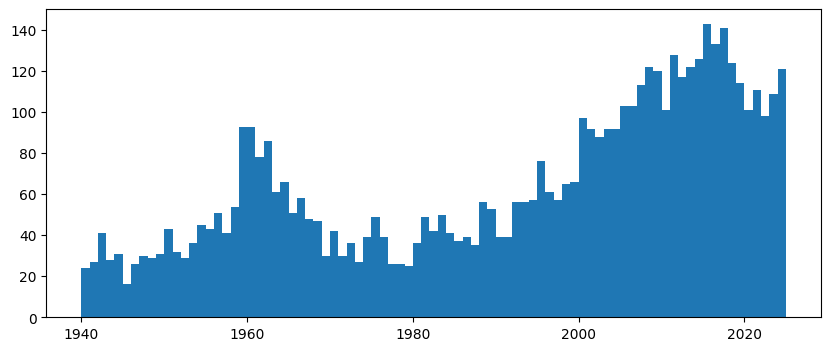

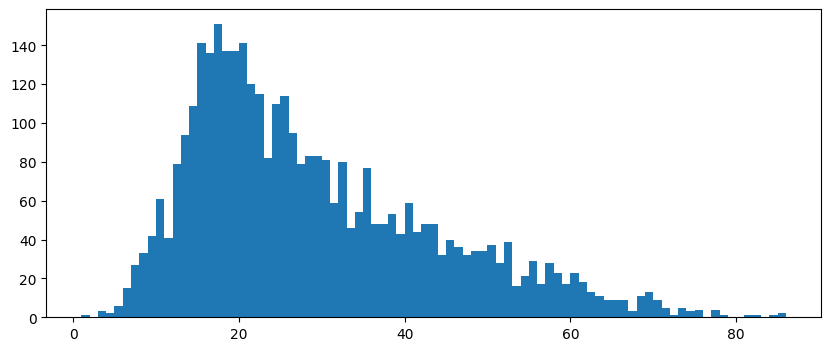

In [6]:
# create dataframe using sharks csv file
df_sharks = pd.read_excel('/content/GSAF5.xls')

df_sharks['Year'] = pd.to_numeric(df_sharks['Year'])

# drop rows with incorrect year values (0000)
df_sharksclean = df_sharks[df_sharks['Year'] != 0000].copy()

# drop rows with missing values
df_sharksclean = df_sharksclean.dropna(subset = ['Year'])

# get range of years
minYear = df_sharksclean['Year'].min()
maxYear = df_sharksclean['Year'].max()

print('oldest year:', minYear)
print('newest year:', maxYear)

print('years that shark attacks occured ranges from 5 to 2026')

# include rows with years after & including 1940
df_sharks_past1940 = df_sharksclean[df_sharksclean['Year'] >= 1940].copy()

# create histogram based on the number of shark attacks each year

# create histogram based on the number of shark attacks each year (10" by 4")
plt.figure(figsize=(10,4))

minYear_1940 = int(df_sharks_past1940['Year'].min())
maxYear_1940 = int(df_sharks_past1940['Year'].max())
plt.hist(df_sharks_past1940['Year'],
         bins = range(minYear_1940, maxYear_1940))

print('the frequency of shark attacks increased in frequency from 1940 to 1960, where they began to drop in frequency until 1980 when they started increasing again. Generally, shark attacks have been increasing in frequency over time')

# clean age column, drop rows with ? for age and remove 's, +, and non-numeric ages
df_sharks_past1940 = df_sharks_past1940[df_sharks_past1940['Age'] != '?']
df_sharks_past1940['Age'] = df_sharks_past1940['Age'].replace("'s",'')
df_sharks_past1940['Age'] = df_sharks_past1940['Age'].replace("+",'')

# convert to numeric
df_sharks_past1940['Age'] = pd.to_numeric(df_sharks_past1940['Age'], errors = 'coerce').dropna()

# create histogram based on the age of victims
plt.figure(figsize=(10,4))
minAge_1940 = int(df_sharks_past1940['Age'].min())
maxAge_1940 = int(df_sharks_past1940['Age'].max())
plt.hist(df_sharks_past1940['Age'],
         bins = range(minAge_1940, maxAge_1940))

# remove observations with missing gender
df_sharks_past1940_genderclean = df_sharks_past1940.copy()
df_sharks_past1940_genderclean = df_sharks_past1940.dropna(subset = ['Age'])

# calculate proportion of male victims
print((df_sharks_past1940_genderclean['Sex'] == "M").sum()/len(df_sharks_past1940_genderclean))

print('0.834 is the proportion of male victims')

# create copy of 1940+ shark attack dataset
df_sharks_past1940_typefilter = df_sharks_past1940.copy()

# define the three allowed types
unknown_type = ['Unknown', 'Invalid', 'Unverified', 'Under investigation', 'Watercraft', 'Questionable', '?', 'Boat', 'Unconfirmed', 'unprovoked']
provoked_type = ['Provoked', ' Provoked']
unprovoked_type = ['Unprovoked', 'Sea Disaster']

# sort each type into a specific type (na, Provoked, or Unprovoked) based on the recorded observation
df_sharks_past1940_typefilter['Type'] = df_sharks_past1940_typefilter['Type'].replace(unknown_type, np.nan)
df_sharks_past1940_typefilter['Type'] = df_sharks_past1940_typefilter['Type'].replace(provoked_type, "Provoked")
df_sharks_past1940_typefilter['Type'] = df_sharks_past1940_typefilter['Type'].replace(unprovoked_type, "Unprovoked")

# replace na with Unknown
df_sharks_past1940_typefilter['Type'] = df_sharks_past1940_typefilter['Type'].fillna("Unknown")

# calculate proportion of unprovoked victims
print((df_sharks_past1940_typefilter['Type'] == "Unprovoked").sum()/len(df_sharks_past1940_typefilter))

print('0.773 is the proportion of unprovoked victims')

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 05adf7160b25c773f349d794b8ae416c4f2b5a95
- **AI tool and model used:** Gemini 3.6 Flash

### *Prompts used

1. [Q1 & Q2]
[my code]
Is there anything wrong or anything that could be improved with my code?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Your Phase 1 script demonstrates solid data cleaning logic, but there are a few critical bugs—particularly around string formatting, histogram binning ranges, and row alignment during assignment—along with several code efficiency optimizations.

Critical Bugs & Fixes
Airbnb Price String Replacement ($ sign missing)

Issue: Prices in Airbnb datasets typically contain dollar signs (e.g., "$1,112"). Stripping only commas keeps the $ sign, causing pd.to_numeric() to convert every price to NaN.

Fix: Strip both $ and , before converting:

Python
df_airbnbclean['Price'] = df_airbnbclean['Price'].astype(str).str.replace(r'[\$,]', '', regex=True)
Shark Attacks Age Assignment Dropna Bug

Issue: Running pd.to_numeric(...).dropna() returns a Series shorter than the DataFrame. Assigning it back (df['Age'] = ...) realigns by index, re-inserting NaNs into the column while keeping empty rows. Furthermore, your replace() calls lacked .str and missed trailing s characters (e.g., "20s").

Fix: Use errors='coerce' to turn text to NaN, then filter rows on the DataFrame level:

Python
df_sharks_past1940['Age'] = pd.to_numeric(df_sharks_past1940['Age'], errors='coerce')
df_sharks_past1940 = df_sharks_past1940.dropna(subset=['Age'])
Histogram Upper Bound Cutoff (range end point)

Issue: range(min, max) excludes max. If the maximum age is 85, your plot stops at 84.

Fix: Add + 2 to the upper bound so the final integer bin is fully included:

Python
bins = range(int(minAge), int(maxAge) + 2)
Dropping Empty Columns (GSAF5.xls)

Issue: Question 2 asks to drop columns that do not contain data, which is currently missing.

Fix: Call .dropna(how='all', axis=1) to purge fully empty columns:

Python
df_sharks = df_sharks.dropna(how='all', axis=1)
Type Cleaning Classification Mistakes

Issue: Replacing 'unprovoked' (lowercase) with np.nan misclassifies unprovoked attacks as Unknown. Similarly, classifying 'Sea Disaster' as Unprovoked or 'Boat'/'Watercraft' as Unknown reinterprets standard GSAF classifications.

Fix: Clean strings directly using .str.strip().str.capitalize(), then map standardized values:

Python
# Standardize casing/spacing first
clean_type = df_sharks_past1940_typefilter['Type'].astype(str).str.strip().str.capitalize()

# Map into the 3 requested categories
valid_types = ['Provoked', 'Unprovoked']
df_sharks_past1940_typefilter['Type'] = clean_type.where(clean_type.isin(valid_types), 'Unknown')
Refactored & Corrected Phase 1 Script
Python
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# QUESTION 1A: AIRBNB PRICE CLEANING
# ==========================================
df_airbnb = pd.read_csv('/content/airbnb_hw.csv')
df_airbnbclean = df_airbnb.copy()

# Remove both dollar signs and commas, then convert to numeric
df_airbnbclean['Price'] = (
    df_airbnbclean['Price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
)
df_airbnbclean['Price'] = pd.to_numeric(df_airbnbclean['Price'], errors='coerce')

missing_prices = df_airbnbclean['Price'].isna().sum()
print(f"Airbnb Missing Prices: {missing_prices}")


# ==========================================
# QUESTION 1B: POLICE USE OF FORCE DATA
# ==========================================
df_police = pd.read_csv('/content/mn_police_use_of_force.csv')
df_policeclean = df_police.copy()

# Calculate missing proportion (where subject_injury is null)
prop_missing = df_policeclean['subject_injury'].isna().mean()
print(f"Proportion of missing injury values: {prop_missing:.3f}")

# Fill missing values for cross-tabulation
df_policeclean['subject_injury_filled'] = df_policeclean['subject_injury'].fillna("Unknown")
print("\nCross-tabulation (Force Type vs. Subject Injury):")
print(pd.crosstab(df_policeclean['force_type'], df_policeclean['subject_injury_filled'], normalize='index'))


# ==========================================
# QUESTION 2: SHARK ATTACK DATASET (GSAF)
# ==========================================
df_sharks = pd.read_excel('/content/GSAF5.xls')

# Drop completely empty columns
df_sharks = df_sharks.dropna(how='all', axis=1)

# Clean 'Year' variable
df_sharks['Year'] = pd.to_numeric(df_sharks['Year'], errors='coerce')
df_sharksclean = df_sharks[df_sharks['Year'] > 0].dropna(subset=['Year']).copy()

print(f"\nYear Range: {int(df_sharksclean['Year'].min())} to {int(df_sharksclean['Year'].max())}")

# Filter for attacks from 1940 onwards
df_sharks_past1940 = df_sharksclean[df_sharksclean['Year'] >= 1940].copy()

# Plot 1: Attack Frequency by Year
plt.figure(figsize=(10, 4))
min_yr, max_yr = int(df_sharks_past1940['Year'].min()), int(df_sharks_past1940['Year'].max())
plt.hist(df_sharks_past1940['Year'], bins=range(min_yr, max_yr + 2), edgecolor='black', color='skyblue')
plt.title('Shark Attacks per Year (1940+)')
plt.xlabel('Year')
plt.ylabel('Attack Count')
plt.tight_layout()
plt.show()

# Clean 'Age' variable
df_sharks_past1940['Age'] = pd.to_numeric(df_sharks_past1940['Age'], errors='coerce')
df_sharks_ageclean = df_sharks_past1940.dropna(subset=['Age']).copy()

# Plot 2: Victim Age Distribution
plt.figure(figsize=(10, 4))
min_age, max_age = int(df_sharks_ageclean['Age'].min()), int(df_sharks_ageclean['Age'].max())
plt.hist(df_sharks_ageclean['Age'], bins=range(min_age, max_age + 2), edgecolor='black', color='teal')
plt.title('Age Distribution of Victims (1940+)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Proportion of Male Victims
df_sex_clean = df_sharks_past1940['Sex'].astype(str).str.strip().str.upper()
prop_male = (df_sex_clean == 'M').mean()
print(f"Proportion of Male Victims: {prop_male:.3f}")

# Clean 'Type' variable into 3 categories: Provoked, Unprovoked, Unknown
clean_type = df_sharks_past1940['Type'].astype(str).str.strip().str.capitalize()
df_sharks_past1940['Type_Clean'] = clean_type.where(clean_type.isin(['Provoked', 'Unprovoked']), 'Unknown')

prop_unprovoked = (df_sharks_past1940['Type_Clean'] == 'Unprovoked').mean()
print(f"Proportion of Unprovoked Attacks: {prop_unprovoked:.3f}")



### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Reject | None of the observations in the price column have a dollar sign |
| 2 | Accept | Allows for more useful data to be kept |
| 3 | Accept | Allows data at the highest value of age to be shown in the histogram |
| 4 | Accept | This is necessary to drop the empty columns that exist in the dataset |
| 5 | Modify | "unprovoked" was mistakenly classified as an unknown type, however the other changes are unnecessary as the current code can do do the same behavior |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [2]:
# Your Phase 2 solution to the problem goes here.
# Your Phase 1 solution to the problem goes here.

# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# create dataframe using airbnb csv file
df_airbnb = pd.read_csv('/content/airbnb_hw.csv')

# create a new dataframe to hold cleaned data
df_airbnbclean = df_airbnb.copy()

# convert price variables from numeric to string to remove comma. This was chosen as it allows the prices to be accessed as numbers and for ease of calculation
df_airbnbclean['Price'] = df_airbnb['Price'].astype(str).str.replace(',','')

# convert price variables from string back to numeric
df_airbnbclean['Price'] = pd.to_numeric(df_airbnbclean['Price'])

# print the sum of null values
print(df_airbnbclean['Price'].isna().sum())

print('interpretation: there are no missing values because all prices with a comma were converted into their non-comma form without any data losses.')

# create dataframe using force csv file
df_police = pd.read_csv('/content/mn_police_use_of_force.csv')

# create a new dataframe to hold cleaned data
df_policeclean = df_police.copy()

# replace missing values with "Unknown" to understand pattern for missing values
df_policeclean['subject_injury'] = df_police['subject_injury'].fillna("Unknown")

# calculate proportion of missing values
print((df_policeclean['subject_injury'] == "Unknown").sum()/len(df_policeclean))

print('0.762 is the proportion of missing values, this is a concern because it demonstrates a gap in police records and non-transparency.')

print(pd.crosstab(df_policeclean['subject_injury'], df_policeclean['force_type']))

print('interpretation: missing injury records tend to proportionally appear more often than recorded injuries for each of the force types.')

0
interpretation: there are no missing values because all prices with a comma were converted into their non-comma form without any data losses.
0.7619342359767892
0.762 is the proportion of missing values, this is a concern because it demonstrates a gap in police records and non-transparency.
force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1093                131        2   
Unknown             2          7051               1421        0   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
No                             33                 34            0   
Unknown                        27                 74           87   
Yes                            44                 40            0   

force_type      Less Let

oldest year: 5.0
newest year: 2026.0
years that shark attacks occured ranges from 5 to 2026
the frequency of shark attacks increased in frequency from 1940 to 1960, where they began to drop in frequency until 1980 when they started increasing again. Generally, shark attacks have been increasing in frequency over time
0.826628895184136
0.827 is the proportion of male victims
0.8158640226628895
0.773 is the proportion of unprovoked victims


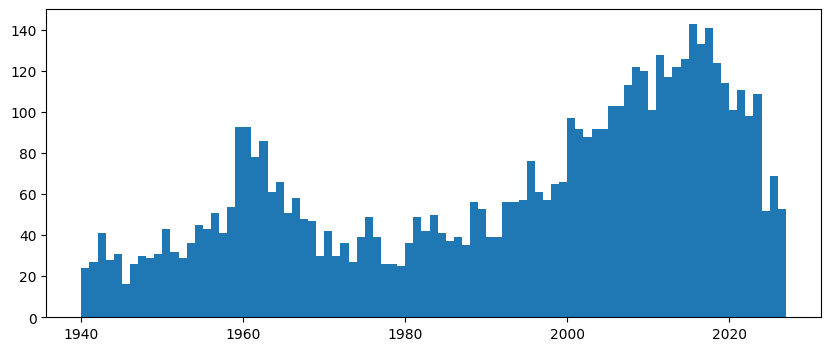

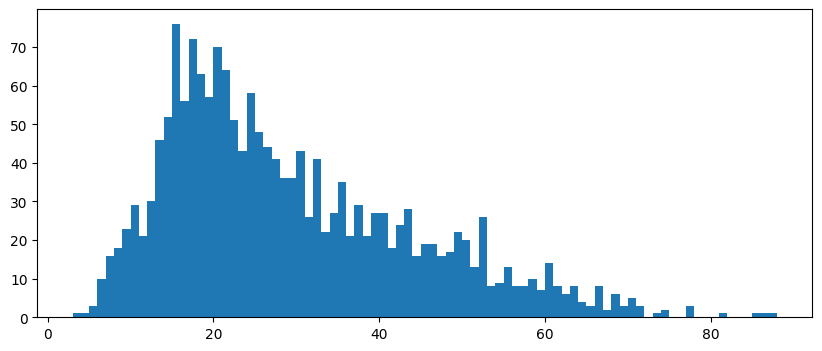

In [8]:
# create dataframe using sharks csv file
df_sharks = pd.read_excel('/content/GSAF5.xls')

df_sharks = df_sharks.dropna(how='all', axis=1)

df_sharks['Year'] = pd.to_numeric(df_sharks['Year'])

# drop rows with incorrect year values (0000)
df_sharksclean = df_sharks[df_sharks['Year'] != 0000].copy()

# drop rows with missing values
df_sharksclean = df_sharksclean.dropna(subset = ['Year'])

# get range of years
minYear = df_sharksclean['Year'].min()
maxYear = df_sharksclean['Year'].max()

print('oldest year:', minYear)
print('newest year:', maxYear)

print('years that shark attacks occured ranges from 5 to 2026')

# include rows with years after & including 1940
df_sharks_past1940 = df_sharksclean[df_sharksclean['Year'] >= 1940].copy()

# create histogram based on the number of shark attacks each year

# create histogram based on the number of shark attacks each year (10" by 4")
plt.figure(figsize=(10,4))

minYear_1940 = int(df_sharks_past1940['Year'].min())
maxYear_1940 = int(df_sharks_past1940['Year'].max())
plt.hist(df_sharks_past1940['Year'],
         bins = range(minYear_1940, maxYear_1940 + 2))

print('the frequency of shark attacks increased in frequency from 1940 to 1960, where they began to drop in frequency until 1980 when they started increasing again. Generally, shark attacks have been increasing in frequency over time')

# clean age column, drop rows with ? for age and remove 's, +, and non-numeric ages
df_sharks_past1940 = df_sharks_past1940[df_sharks_past1940['Age'] != '?']
df_sharks_past1940['Age'] = df_sharks_past1940['Age'].str.replace("'s",'')
df_sharks_past1940['Age'] = df_sharks_past1940['Age'].str.replace("+",'')

# convert to numeric
df_sharks_past1940['Age'] = pd.to_numeric(df_sharks_past1940['Age'], errors='coerce')
df_sharks_past1940 = df_sharks_past1940.dropna(subset=['Age'])

# create histogram based on the age of victims
plt.figure(figsize=(10,4))
minAge_1940 = int(df_sharks_past1940['Age'].min())
maxAge_1940 = int(df_sharks_past1940['Age'].max())
plt.hist(df_sharks_past1940['Age'],
         bins = range(minAge_1940, maxAge_1940 + 2))

# remove observations with missing gender
df_sharks_past1940_genderclean = df_sharks_past1940.copy()
df_sharks_past1940_genderclean = df_sharks_past1940.dropna(subset = ['Age'])

# calculate proportion of male victims
print((df_sharks_past1940_genderclean['Sex'] == "M").sum()/len(df_sharks_past1940_genderclean))

print('0.827 is the proportion of male victims')

# create copy of 1940+ shark attack dataset
df_sharks_past1940_typefilter = df_sharks_past1940.copy()

# define the three allowed types
unknown_type = ['Unknown', 'Invalid', 'Unverified', 'Under investigation', 'Watercraft', 'Questionable', '?', 'Boat', 'Unconfirmed']
provoked_type = ['Provoked', ' Provoked']
unprovoked_type = ['Unprovoked', 'unprovoked', 'Sea Disaster']

# sort each type into a specific type (na, Provoked, or Unprovoked) based on the recorded observation
df_sharks_past1940_typefilter['Type'] = df_sharks_past1940_typefilter['Type'].replace(unknown_type, np.nan)
df_sharks_past1940_typefilter['Type'] = df_sharks_past1940_typefilter['Type'].replace(provoked_type, "Provoked")
df_sharks_past1940_typefilter['Type'] = df_sharks_past1940_typefilter['Type'].replace(unprovoked_type, "Unprovoked")

# replace na with Unknown
df_sharks_past1940_typefilter['Type'] = df_sharks_past1940_typefilter['Type'].fillna("Unknown")

# calculate proportion of unprovoked victims
print((df_sharks_past1940_typefilter['Type'] == "Unprovoked").sum()/len(df_sharks_past1940_typefilter))

print('0.773 is the proportion of unprovoked victims')

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

AI helped correct issues for cleaning the data and ensuring that the questions are fully answered. The solutions provided by the AI was verified by replacing the old code with the AI generated code and running the code block again, noting any differences in the original output and new output. However, there were several limitations in the AI's response and recommendations because it couldn't see what the original dataset was, which resulted in proposed changes that didn't apply to the dataset used, for example, the Price column. Additionally, it may propose code changes that may optimize the code, but aren't strictly necessary. An example of this is the code provided for categorizing the different incident types as it didn't affect any of the code's behavior. My remaining concerns about the use of AI for this assignment are whether AI is capable of understanding what is desired from datasets, meaning whether or not it can judge what data should and shouldn't be kept because it seems like a very subjective area of data science.